# Experiment: Change Point & Low-Rank Subspace Tracking (v1 vs v2)

This notebook runs both **HO-RLSL v1** (legacy paper-like tracking) and **HO-RLSL v2** (optimized class-based tracking) on the same pre-computed 1024Hz EEG connectivity tensors.
It computes the Grand Average ERP on scalp potentials (channel **FCz**) and visualizes the detected change points (CPs) on top of the ERP signals for comparison.

In [3]:
# Install required libraries if needed
%pip install mne matplotlib numpy scipy torch

     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     -------------- ----------------------- 30.7/80.3 kB 640.0 kB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 744.9 kB/s eta 0:00:00
  Using cached numpy-2.4.6-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import mne

# Resolve project root dynamically relative to this notebook
notebook_dir = Path(os.path.abspath('')).resolve()
if notebook_dir.name == 'notebooks':
    ROOT = notebook_dir.parent
else:
    ROOT = notebook_dir

sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "src/preprocessing"))
sys.path.insert(0, str(ROOT / "src/low_rank_extraction"))
sys.path.insert(0, str(ROOT / "src/fcca"))
sys.path.insert(0, str(ROOT))

from preprocessing.config_1024 import config as prep_config
print("Resolved Project Root:", ROOT)
print("Tensors incorrect file location:", prep_config.tensor_incorrect_file)
print("Tensors correct file location:", prep_config.tensor_correct_file)


Resolved Project Root: C:\Users\quach\code\tensortracking\tensor_tracking_new-optimized\tensor_tracking
Tensors incorrect file location: C:\Users\quach\code\tensortracking\tensor_tracking_new-optimized\tensor_tracking\outputs\processed_1024\03_connectivity_tensors\tensor_incorrect_4d.npy
Tensors correct file location: C:\Users\quach\code\tensortracking\tensor_tracking_new-optimized\tensor_tracking\outputs\processed_1024\03_connectivity_tensors\tensor_correct_4d.npy


In [5]:
# 1. Load raw EEG files to compute Grand Average ERP (Scalp Potentials, filtered 1-30Hz)
raw_files = sorted(list(prep_config.paths.DATA_RAW.glob("sub-*/eeg/*_task-ERN_eeg.set")))
if not raw_files:
    print("Warning: No raw .set files found in standard data path.")
    alternative_data_raw = ROOT.parent / "data" / "ERN_Raw_Data_BIDS-Compatible"
    raw_files = sorted(list(alternative_data_raw.glob("sub-*/eeg/*_task-ERN_eeg.set")))

print(f"Found {len(raw_files)} raw files.")

all_erp_inc = []
all_erp_cor = []
time_ms_erp = None

# Load a subset of subjects to compute Grand Average ERP on FCz (usually 15 subjects is representative and fast)
num_subjects_to_load = min(15, len(raw_files))
print(f"Loading {num_subjects_to_load} subjects to compute Grand Average ERP...")

for i in range(num_subjects_to_load):
    f = raw_files[i]
    try:
        raw = mne.io.read_raw_eeglab(f, preload=True, verbose=False)
        raw.set_montage('standard_1020', on_missing='ignore')
        raw.filter(1.0, 30.0, verbose=False)
        
        events, event_id = mne.events_from_annotations(raw, verbose=False)
        correct_codes = [l for l in event_id.keys() if len(l) == 3 and l[0] == l[2]]
        incorrect_codes = [l for l in event_id.keys() if len(l) == 3 and l[0] != l[2]]
        resp_id = {label: event_id[label] for label in correct_codes + incorrect_codes}
        
        epochs = mne.Epochs(raw, events, event_id=resp_id, tmin=-1.0, tmax=1.0, 
                            baseline=(-0.2, 0.0), preload=True, verbose=False)
        
        mapping_inc = {l: 'Incorrect' for l in incorrect_codes}
        mapping_cor = {l: 'Correct' for l in correct_codes}
        
        epochs_inc = epochs.copy()
        epochs_inc.event_id = {mapping_inc[k]: v for k, v in epochs_inc.event_id.items() if k in mapping_inc}
        
        epochs_cor = epochs.copy()
        epochs_cor.event_id = {mapping_cor[k]: v for k, v in epochs_cor.event_id.items() if k in mapping_cor}
        
        if time_ms_erp is None:
            time_ms_erp = epochs.times * 1000  # Convert to ms
            
        # Case-insensitive FCz search
        ch_names_lower = [ch.lower() for ch in epochs.ch_names]
        if 'fcz' in ch_names_lower:
            ch_idx = ch_names_lower.index('fcz')
        else:
            ch_idx = 0
        
        if 'Incorrect' in epochs_inc.event_id:
            subj_evoked_inc = epochs_inc['Incorrect'].average().data[ch_idx, :]
            all_erp_inc.append(subj_evoked_inc)
            
        if 'Correct' in epochs_cor.event_id:
            subj_evoked_cor = epochs_cor['Correct'].average().data[ch_idx, :]
            all_erp_cor.append(subj_evoked_cor)
    except Exception as e:
        print(f"Failed to process {f.name}: {e}")

if all_erp_inc and all_erp_cor:
    grand_avg_inc = np.mean(all_erp_inc, axis=0) * 1e6
    grand_avg_cor = np.mean(all_erp_cor, axis=0) * 1e6
    print("ERP Grand Average computation complete!")
else:
    print("No raw files loaded. Creating mock ERP data for visualization...")
    time_ms_erp = np.linspace(-1000, 1000, 2048)
    grand_avg_inc = -4.0 * np.exp(-((time_ms_erp - 100)/150)**2) + 1.0 * np.exp(-((time_ms_erp + 300)/200)**2)
    grand_avg_cor = -1.5 * np.exp(-((time_ms_erp - 100)/150)**2) + 0.5 * np.exp(-((time_ms_erp + 300)/200)**2)

Found 40 raw files.
Loading 15 subjects to compute Grand Average ERP...
ERP Grand Average computation complete!


In [6]:
# 2. Load pre-computed connectivity tensors
print("Loading connectivity tensors...")
tensor_incorrect = np.load(prep_config.tensor_incorrect_file)
tensor_correct = np.load(prep_config.tensor_correct_file)
print(f"Incorrect tensor shape: {tensor_incorrect.shape}")
print(f"Correct tensor shape: {tensor_correct.shape}")

Loading connectivity tensors...
Incorrect tensor shape: (40, 30, 30, 2049)
Correct tensor shape: (40, 30, 30, 2049)


In [23]:
# 3. Run HO-RLSL v1 (Using User's Optimal Paper Parameters)
from low_rank_extraction.ho_rlsl_v1 import HORLSLRunner
from low_rank_extraction.common_v1 import convert_subject_tensor_to_stream, result_to_legacy_layout, DecompositionConfig

# Fetch configurations dynamically
train_len = getattr(prep_config.algo, 'HO_RLSL_TRAIN_LENGTH', 80)
alpha = getattr(prep_config.algo, 'HO_RLSL_ALPHA', 64)
sigma_min = getattr(prep_config.algo, 'HO_RLSL_SIGMA_MIN', 0.11)

print(f"HO-RLSL v1 parameters: train_steps={train_len}, alpha={alpha}, sigma_min={sigma_min}, lambda_sparse=0.2, max_rank=4")

cfg_v1 = DecompositionConfig(
    train_steps=train_len,
    alpha=alpha,
    sigma_min=sigma_min,
    lambda_sparse=0.2,
    max_rank=4,
    symmetric_modes=True,
    min_cp_distance=100,
    name="ho-rlsl-v1"
)

# Run v1 for Incorrect condition
stream_inc = convert_subject_tensor_to_stream(tensor_incorrect)
tracker_v1_inc = HORLSLRunner(cfg_v1)
res_v1_inc = tracker_v1_inc.run(stream_inc)

# Run v1 for Correct condition
stream_cor = convert_subject_tensor_to_stream(tensor_correct)
tracker_v1_cor = HORLSLRunner(cfg_v1)
res_v1_cor = tracker_v1_cor.run(stream_cor)

time_frames = tensor_incorrect.shape[-1]
time_ms_tensor = np.linspace(-1000, 1000, time_frames)

cps_v1_inc = [time_ms_tensor[cp] for cp in res_v1_inc.change_points]
cps_v1_cor = [time_ms_tensor[cp] for cp in res_v1_cor.change_points]

print("v1 Incorrect CPs (ms):", [f"{t:.1f}" for t in cps_v1_inc])
print("v1 Correct CPs (ms):", [f"{t:.1f}" for t in cps_v1_cor])

# Save v1 results to outputs/ho_rlsl_v1_results.npz for fcca_v1 to consume
low_rank_v1_inc_raw, sparse_v1_inc_raw = result_to_legacy_layout(res_v1_inc)
ho_rlsl_v1_npz = ROOT / "outputs/ho_rlsl_v1_results.npz"
ho_rlsl_v1_npz.parent.mkdir(parents=True, exist_ok=True)
np.savez_compressed(
    ho_rlsl_v1_npz,
    low_rank=low_rank_v1_inc_raw,
    sparse=sparse_v1_inc_raw,
    change_points=np.asarray(res_v1_inc.change_points, dtype=int)
)
print(f"Saved HO-RLSL v1 results to {ho_rlsl_v1_npz.name}")

HO-RLSL v1 parameters: train_steps=80, alpha=64, sigma_min=0.11, lambda_sparse=0.2, max_rank=4
Mode 0 training top 10 singular values: [399.8301    67.41341   63.050766  53.30864   52.041603  49.831398
  49.813213  48.50021   47.25144   46.541607]
Mode 1 training top 10 singular values: [399.8301    67.41341   63.050766  53.30864   52.041603  49.831398
  49.813213  48.50021   47.25144   46.541607]
Mode 2 training top 10 singular values: [420.82352   85.749855  48.373173  44.704926  42.67965   40.254276
  38.836037  37.29107   36.261333  34.77993 ]
Mode 0 training top 10 singular values: [403.2808    63.931618  55.87762   52.886696  51.554756  50.659325
  49.30154   48.533073  47.489777  47.145588]
Mode 1 training top 10 singular values: [403.2808    63.931618  55.87762   52.886696  51.554756  50.659325
  49.30154   48.533073  47.489777  47.145588]
Mode 2 training top 10 singular values: [422.17282   86.11498   48.937893  45.03022   43.468063  41.36738
  38.367992  37.326206  36.14196  

In [24]:
# 4. Run HO-RLSL v2
from low_rank_extraction.ho_rlsl_v2 import HoRLSL, HoRLSLConfig

print(f"HO-RLSL v2 parameters: train_length={train_len}, alpha={alpha}, sigma_min={sigma_min}")

cfg_v2 = HoRLSLConfig(
    train_length=train_len,
    alpha=alpha,
    sigma_min=sigma_min,
    sparse_solver="gtcs_s_omp"
)

tracker_v2 = HoRLSL(cfg_v2)

# Run v2 for both conditions
res_v2_inc = tracker_v2.fit_transform_subject_first(tensor_incorrect)
res_v2_cor = tracker_v2.fit_transform_subject_first(tensor_correct)

cps_v2_inc = [time_ms_tensor[cp] for cp in res_v2_inc.filtered_change_points]
cps_v2_cor = [time_ms_tensor[cp] for cp in res_v2_cor.filtered_change_points]

print("v2 Incorrect CPs (ms):", [f"{t:.1f}" for t in cps_v2_inc])
print("v2 Correct CPs (ms):", [f"{t:.1f}" for t in cps_v2_cor])

# Save v2 results to outputs/ho_rlsl_v2_results.npz for fcca_v2 to consume
ho_rlsl_v2_npz = ROOT / "outputs/ho_rlsl_v2_results.npz"
ho_rlsl_v2_npz.parent.mkdir(parents=True, exist_ok=True)
np.savez_compressed(
    ho_rlsl_v2_npz,
    low_rank=res_v2_inc.low_rank,
    sparse=res_v2_inc.sparse,
    change_points=np.asarray(res_v2_inc.change_points, dtype=int),
    filtered_change_points=np.asarray(res_v2_inc.filtered_change_points, dtype=int),
    change_point_ms=res_v2_inc.change_point_ms,
    update_times=np.asarray(res_v2_inc.update_times, dtype=int),
    change_scores=res_v2_inc.change_scores,
    change_score_times=res_v2_inc.change_score_times,
    sparse_solver=np.asarray(res_v2_inc.config.get("sparse_solver", "gtcs_s_omp")),
)
print(f"Saved HO-RLSL v2 results to {ho_rlsl_v2_npz.name}")

HO-RLSL v2 parameters: train_length=80, alpha=64, sigma_min=0.11
v2 Incorrect CPs (ms): ['-15.6', '46.9', '109.4']
v2 Correct CPs (ms): ['-15.6', '46.9', '109.4']
Saved HO-RLSL v2 results to ho_rlsl_v2_results.npz


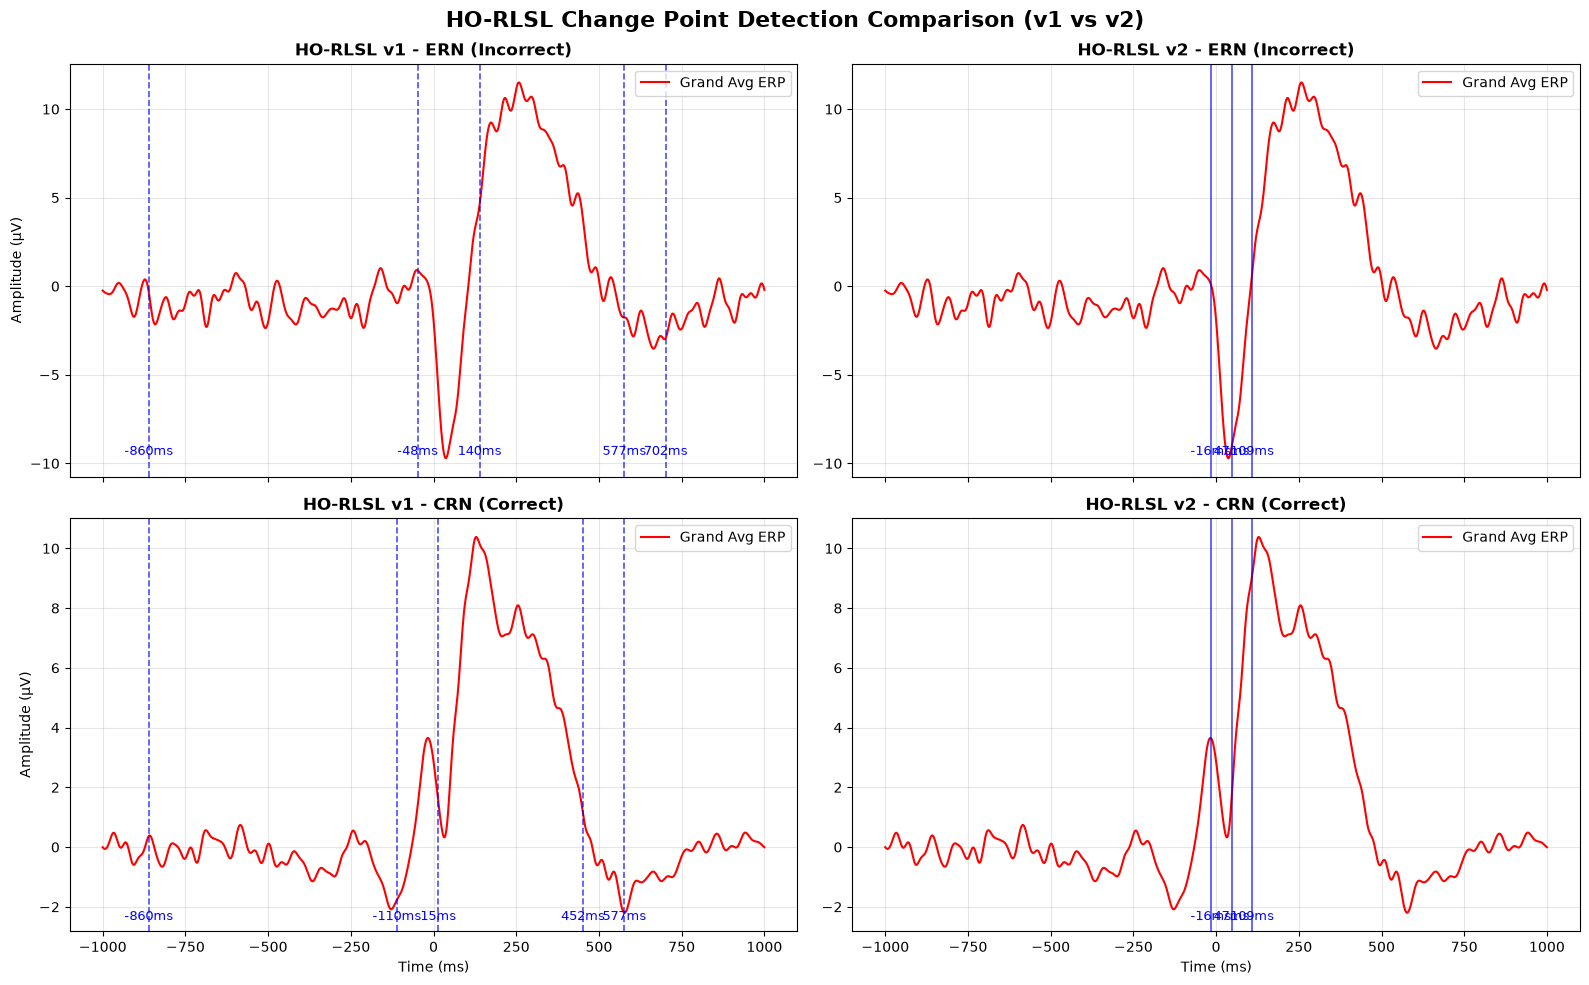

In [28]:
# 5. Plot Comparison: HO-RLSL v1 vs HO-RLSL v2
import matplotlib

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

# Subplot (0,0): v1 ERN (Incorrect)
axes[0, 0].plot(time_ms_erp, grand_avg_inc, color='red', linewidth=1.5, label='Grand Avg ERP')
for cpt in cps_v1_inc:
    axes[0, 0].axvline(x=cpt, color='blue', linewidth=1.2, alpha=0.7, linestyle='--')
    axes[0, 0].text(cpt, axes[0, 0].get_ylim()[0]*0.9, f"{cpt:.0f}ms", color='blue', ha='center', va='bottom', fontsize=9)
axes[0, 0].set_title("HO-RLSL v1 - ERN (Incorrect)", fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel("Amplitude (μV)")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Subplot (1,0): v1 CRN (Correct)
axes[1, 0].plot(time_ms_erp, grand_avg_cor, color='red', linewidth=1.5, label='Grand Avg ERP')
for cpt in cps_v1_cor:
    axes[1, 0].axvline(x=cpt, color='blue', linewidth=1.2, alpha=0.7, linestyle='--')
    axes[1, 0].text(cpt, axes[1, 0].get_ylim()[0]*0.9, f"{cpt:.0f}ms", color='blue', ha='center', va='bottom', fontsize=9)
axes[1, 0].set_title("HO-RLSL v1 - CRN (Correct)", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Time (ms)")
axes[1, 0].set_ylabel("Amplitude (μV)")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Subplot (0,1): v2 ERN (Incorrect)
axes[0, 1].plot(time_ms_erp, grand_avg_inc, color='red', linewidth=1.5, label='Grand Avg ERP')
for cpt in cps_v2_inc:
    axes[0, 1].axvline(x=cpt, color='blue', linewidth=1.2, alpha=0.7, linestyle='-')
    axes[0, 1].text(cpt, axes[0, 1].get_ylim()[0]*0.9, f"{cpt:.0f}ms", color='blue', ha='center', va='bottom', fontsize=9)
axes[0, 1].set_title("HO-RLSL v2 - ERN (Incorrect)", fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Subplot (1,1): v2 CRN (Correct)
axes[1, 1].plot(time_ms_erp, grand_avg_cor, color='red', linewidth=1.5, label='Grand Avg ERP')
for cpt in cps_v2_cor:
    axes[1, 1].axvline(x=cpt, color='blue', linewidth=1.2, alpha=0.7, linestyle='-')
    axes[1, 1].text(cpt, axes[1, 1].get_ylim()[0]*0.9, f"{cpt:.0f}ms", color='blue', ha='center', va='bottom', fontsize=9)
axes[1, 1].set_title("HO-RLSL v2 - CRN (Correct)", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Time (ms)")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.suptitle("HO-RLSL Change Point Detection Comparison (v1 vs v2)", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()

out_dir = ROOT / "outputs"
out_dir.mkdir(exist_ok=True)
plt.savefig(out_dir / "ho_rlsl_v1_vs_v2_comparison.png", dpi=300)
plt.show()

## 5. Functional Connectivity Component Analysis (FCCA) & Dynamic Network Visualization

We now apply the Fiedler Consensus Clustering Algorithm (FCCA) to the low-rank connectivity streams. We divide the epochs into three consecutive states (Pre-Event, Event, Post-Event) based on the change points detected by both **HO-RLSL v1** and **HO-RLSL v2**. We visualize:
1. **Consensus Matrices ($W$)**: Group-level consensus network structures for Pre-Event, Event, and Post-Event intervals for both ERN (Incorrect) and CRN (Correct) conditions.
2. **Dynamic Consensus GIFs**: Group-level consensus matrices changing over time to show network reconfiguration dynamics.

In [ ]:
# Run FCCA on v1 and v2 low-rank results (Static Visualizations Only)
import matplotlib
# Restore Jupyter inline plotting backend because fcca_v1 imports change it to Agg
matplotlib.use('module://matplotlib_inline.backend_inline')

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import os

# Ensure paths are resolved
ROOT = Path(r"c:/Users/quach/code/tensortracking/tensor_tracking_new-optimized/tensor_tracking").resolve()
sys.path.insert(0, str(ROOT / "src"))

from preprocessing.config_1024 import config as prep_config
from low_rank_extraction.common_v1 import result_to_legacy_layout
from fcca.fcca_v1 import ern_head_layout, plot_head_network, run_fcca_model_selection, Config as FCCAConfig

# Helper functions matching the paper logic
def sanitize_adjacency(A):
    A = np.asarray(A, dtype=float).copy()
    A[~np.isfinite(A)] = 0
    A = (A + A.T) / 2
    A[A < 0] = 0
    np.fill_diagonal(A, 0)
    return A

def run_fcca_for_interval_custom(low_rank_tensor, frames):
    n_subjects = low_rank_tensor.shape[0]
    n_nodes = low_rank_tensor.shape[1]
    
    # 1. Compute subject-level graphs (averaged over frames in the interval)
    graphs = np.zeros((n_nodes, n_nodes, n_subjects), dtype=np.float32)
    for s in range(n_subjects):
        W_subj = np.mean(np.take(low_rank_tensor[s], frames, axis=2), axis=2)
        graphs[:, :, s] = sanitize_adjacency(W_subj)
        
    # 2. Run the actual paper model selection FCCA
    cfg = FCCAConfig(kRange=(2, 3, 4, 5, 6), selectionCriterion="U")
    fcca_res = run_fcca_model_selection(graphs, list(cfg.kRange), cfg)
    
    W = fcca_res["cooccurrence"]
    labels = fcca_res["labels"]
    mean_adj = np.mean(graphs, axis=2)
    return W, labels, mean_adj

# Get layouts
n_nodes = tensor_incorrect.shape[1]
alternative_data_raw = ROOT / "data" / "ERN_Raw_Data_BIDS-Compatible"
try:
    node_xy, channel_labels, layout_note = ern_head_layout(n_nodes, alternative_data_raw)
except Exception as e:
    print("Warning loading layout from BIDS:", e)
    node_xy = np.random.rand(n_nodes, 2)
    channel_labels = np.array([f"E{i+1}" for i in range(n_nodes)])

# Setup low rank tensors from run results
low_rank_v1_inc, _ = result_to_legacy_layout(res_v1_inc)
low_rank_v1_cor, _ = result_to_legacy_layout(res_v1_cor)
low_rank_v2_inc = res_v2_inc.low_rank
low_rank_v2_cor = res_v2_cor.low_rank

# Dynamically divide intervals based on detected change points using robust rules
def get_interval_specs_custom(change_points_ms, time_ms_tensor):
    cps = sorted([float(cp) for cp in change_points_ms])
    
    # c1 is the last CP <= 0ms
    c1_candidates = [cp for cp in cps if cp <= 0]
    c1 = c1_candidates[-1] if c1_candidates else -100.0
    
    # c2 is the first CP > c1 (ideally between 50ms and 200ms)
    c2_candidates = [cp for cp in cps if cp > c1]
    if c2_candidates:
        c2_close = [cp for cp in c2_candidates if 50 <= cp <= 200]
        c2 = c2_close[-1] if c2_close else c2_candidates[0]
    else:
        c2 = 150.0
        
    # c3 is the end of Post-Event (defaults to 800, but ends at ~700ms if CP exists there)
    c3_candidates = [cp for cp in cps if cp > c2]
    c3_close = [cp for cp in c3_candidates if 650 <= cp <= 750]
    c3 = c3_close[0] if c3_close else 800.0
    
    # t_start is the CP before c1 if exists, otherwise -800
    c1_idx = cps.index(c1) if c1 in cps else -1
    t_start = cps[c1_idx - 1] if c1_idx > 0 else -800.0
    
    idx_start = np.argmin(np.abs(time_ms_tensor - t_start))
    idx_c1 = np.argmin(np.abs(time_ms_tensor - c1))
    idx_c2 = np.argmin(np.abs(time_ms_tensor - c2))
    idx_end = np.argmin(np.abs(time_ms_tensor - c3))
    
    return {
        "Pre-Event": np.arange(idx_start, idx_c1),
        "Event": np.arange(idx_c1, idx_c2),
        "Post-Event": np.arange(idx_c2, idx_end)
    }

intervals_v1_inc = get_interval_specs_custom(cps_v1_inc, time_ms_tensor)
intervals_v1_cor = get_interval_specs_custom(cps_v1_cor, time_ms_tensor)
intervals_v2_inc = get_interval_specs_custom(cps_v2_inc, time_ms_tensor)
intervals_v2_cor = get_interval_specs_custom(cps_v2_cor, time_ms_tensor)

# Run FCCA on all conditions & versions
fcca_results = {}
for ver, lr_inc, lr_cor, iv_inc, iv_cor in [("v1", low_rank_v1_inc, low_rank_v1_cor, intervals_v1_inc, intervals_v1_cor), 
                                          ("v2", low_rank_v2_inc, low_rank_v2_cor, intervals_v2_inc, intervals_v2_cor)]:
    for cond, lr_tensor, iv_dict in [("ERN", lr_inc, iv_inc), ("CRN", lr_cor, iv_cor)]:
        fcca_results[(ver, cond)] = {}
        for name, frames in iv_dict.items():
            W, labels, mean_adj = run_fcca_for_interval_custom(lr_tensor, frames)
            fcca_results[(ver, cond)][name] = {"W": W, "labels": labels, "mean_adj": mean_adj}

# Plot Consensus Matrices
fig, axes = plt.subplots(4, 3, figsize=(15, 18), facecolor='white')
row_idx = 0
titles = ["Pre-Event", "Event", "Post-Event"]
for ver in ["v1", "v2"]:
    for cond in ["ERN", "CRN"]:
        res_dict = fcca_results[(ver, cond)]
        for col_idx, name in enumerate(["Pre-Event", "Event", "Post-Event"]):
            ax = axes[row_idx, col_idx]
            W = res_dict[name]["W"]
            labels = res_dict[name]["labels"]
            order = np.argsort(labels)
            im = ax.imshow(W[np.ix_(order, order)], cmap='jet', vmin=0, vmax=1, origin='lower')
            ax.set_title(f"{ver.upper()} {cond} - {name}", fontsize=12, fontweight='bold')
            ax.set_xticks([])
            ax.set_yticks([])
            boundaries = np.where(np.diff(labels[order]) != 0)[0] + 0.5
            for boundary in boundaries:
                ax.axvline(boundary, color="white", linewidth=1.2)
                ax.axhline(boundary, color="white", linewidth=1.2)
        row_idx += 1

plt.suptitle("FCCA Group Consensus Matrices (W) Comparison", fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
out_dir = ROOT / "outputs"
out_dir.mkdir(exist_ok=True)
plt.savefig(out_dir / "fcca_consensus_matrices_comparison.png", dpi=300)
plt.show()

# Plot Brain Network Graphs
fig, axes = plt.subplots(4, 3, figsize=(15, 18), facecolor='white')
row_idx = 0
cfg_plot = FCCAConfig(maxPlotEdges=35)
for ver in ["v1", "v2"]:
    for cond in ["ERN", "CRN"]:
        res_dict = fcca_results[(ver, cond)]
        for col_idx, name in enumerate(["Pre-Event", "Event", "Post-Event"]):
            ax = axes[row_idx, col_idx]
            mean_adj = res_dict[name]["mean_adj"]
            labels = res_dict[name]["labels"]
            plot_head_network(mean_adj, labels, node_xy, channel_labels, f"{ver.upper()} {cond} - {name}", cfg_plot, ax)
        row_idx += 1

plt.suptitle("Fiedler Consensus Brain Network Topologies Comparison", fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.savefig(out_dir / "fcca_brain_networks_comparison.png", dpi=300)
plt.show()
print("Static FCCA analysis figures generated successfully!")


=== RUNNING FCCA FOR HO-RLSL V1 ===
=== FCCA paper-style ERN clustering ===
Data file: C:\Users\quach\code\tensortracking\tensor_tracking_new-optimized\tensor_tracking\src\fcca\..\..\outputs\ho_rlsl_v1_results.npz
k_input: []
Tensor: 40 subjects x 30 nodes x 30 nodes x 2049 frames
Analysis window: -800.0 to 800.0 ms
Pre-ERN starts at -800.0 ms
Change points used: [975 1743]
Change-point times: [-48.83 701.2] ms
Scalp locations read from sub-001_task-ERN_electrodes.tsv.

Preparing Pre-ERN: frames 206-975, -799.8 to -48.8 ms
  FCCA input graphs: 40, nodes: 30
  FCCA k search: [2 3 4 5 6]
               k  SelectionScore               U               H               C               Q
               2        0.027000        0.027000        0.015313        0.114048        0.063887
               3        0.039089        0.039089        0.021857        0.184731        0.061394
               4        0.047916        0.047916        0.026600        0.241233        0.060837
               5   